In [11]:
# Colab setup -- installs SoftMobility when running on Google Colab.
# Safe to run locally: it does nothing outside Colab.
try:
    import google.colab  # noqa: F401
    %pip install -q git+https://github.com/C0PEP0D/SoftMobility.git
except ImportError:
    pass

# Example 04. Flexible fiber in shear flow

We want to simulate the deformation and tumbling of a flexible fiber in 
shear flow. 

The fiber is modeled as an instance of the `FlexibleFiber` class, with
`intrinsic_curvature = KAPPA_0`. The global variable `KAPPA_0` controls 
the rest-state curvature, it is set to a small value: $\kappa_0 = 0.01/L$.

## Convention

- Lab frame: flow direction ${\mathbf{e}}_1$, gradient direction
  ${\mathbf{e}}_2$ (default of `sm.shear_flow`), vorticity
  direction $-{\mathbf{e}}_3$.
- Shear flow $\mathbf{u}^\infty(\mathbf{r})=\dot\gamma y\,{\mathbf{e}}_1$,
  $\dot\gamma = 1$. Shear plane is $\mathbf{e}_1$-$\mathbf{e}_2$.
- The fiber is made of $N$ touching spheres
- Sphere radius $a = 1$, fluid viscosity $\mu = 1$.
- Rigid bonds of length $2a$ (no extensibility, no gap).
- Chain length between end-sphere centres $L = (N-1) 2a$.

## Dimensionless bending stiffness
We introduce the dimensionless bending stiffness

$$\bar B = \frac{B}{8\pi\,\mu\,\dot\gamma\,a^4},$$

with $B$ the bending rigidity, which is $(\pi/4)E a^4$ for a beam of radius $a$.

For $a=\mu=\dot\gamma=1$, $\bar B = B/(8\pi)$, and we use $\bar B = 200$, soft enough that even a tiny
intrinsic curvature seeds dramatic buckling during the tumbling phase.

## Initial orientation

`FlexibleFiber(planar=True)` create a fiber aligned with $\mathbf{E}_1$, 
which bends in the **body** $\mathbf{E}_1$-$\mathbf{E}_3$ plane. 
To align that bending plane with the **lab** shear plane 
$\mathbf{e}_1$-$\mathbf{e}_2$, we use an initial orientation vector 
$\boldsymbol{\theta}_0 = [\pi/2, 0, 0]$.

## Imports

In [12]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import softmobility as sm
from softmobility.classes import figstyle

jax.config.update("jax_enable_x64", True)
figstyle.apply()
np.set_printoptions(precision=4, linewidth=120, suppress=True, sign=" ")

FIGDIR = "figures"

## Helpers

Copied from `softmobility/examples/02_sinking_fiber.ipynb`: lab-frame
bead positions from `rollout` output, and the snapshot drawing helpers.


In [13]:
def lab_bead_positions(fiber, positions, orientations, dofs, design=None):
    """Return an array of shape (n_steps, n_beads, 3) with lab-frame bead positions."""
    if design is None:
        design = np.asarray(fiber.design_defaults)
    n_steps = int(positions.shape[0])
    n_beads = fiber.Nspheres
    t_dummy = np.array([0.0])
    out = np.zeros((n_steps, n_beads, 3))
    body_frame_positions = np.zeros((n_beads, 3))
    for step in range(n_steps):
        dof_step = np.asarray(dofs[step])
        for i in range(n_beads):
            body_frame_positions[i] = np.asarray(
                fiber.spheres[i].position(dof_step, design, t_dummy)
            )
        R = np.asarray(sm.rotation_matrix(orientations[step]))
        out[step] = np.asarray(positions[step]) + body_frame_positions @ R.T
    return out


def draw_shape(ax, beads_xy, *, color, fill, line_width=1.5,
               bead_radius=1.0, opacity=1.0):
    """Draw a fiber as a connecting line plus one filled circle per bead."""
    xs, ys = beads_xy[:, 0], beads_xy[:, 1]
    ax.plot(xs, ys, color=color, linewidth=line_width, alpha=opacity)
    for cx, cy in zip(xs, ys, strict=True):
        ax.add_patch(plt.Circle(
            (cx, cy), bead_radius,
            edgecolor=color, facecolor=fill, linewidth=1.0, alpha=opacity,
        ))


def stack_shape(snapshot_xy, row_index, y_step):
    """Centre an (n_beads, 2) snapshot at the origin then shift down by row_index*y_step."""
    centred = snapshot_xy - snapshot_xy.mean(axis=0)
    centred = centred.copy()
    centred[:, 1] -= row_index * y_step
    return centred

## 1. Parameters and body

Build the planar `FlexibleFiber` with intrinsic curvature `KAPPA_0`.
Edit any of the four globals below to retune the simulation.

In [14]:
# ===== User-tunable globals =====
N = 15                      # number of beads
radius = 1.0                # bead radius
SHEAR_RATE = 1.0            # flow shear rate
B_BAR = 200.0               # dimensionless bending rigidity
INTRINSIC_CURVATURE = 0.01  # intrinsic curvature (in units of L_chain⁻¹)

bending_rigidity = B_BAR * 8 * np.pi 
L_chain = (N - 1) * 2.0 * radius
kappa_0 = 0.01/ L_chain
# =================================

print(f"N = {N},  a = {radius},  L_chain = {L_chain}")
print(f"B = {bending_rigidity},  A = B/(8π) = {bending_rigidity / (8 * np.pi):.4f}")
print(f"κ_0 = 1/(100·L) = {kappa_0:.5g}  (a⁻¹)")
print(f"per-bond rest Δθ = 2a·κ_0 = {2 * radius * kappa_0:.5g}  (rad)")

fiber = sm.FlexibleFiber(
    n_beads=N,
    radius=radius,
    bending_rigidity=bending_rigidity,
    mass=0.0,            # no gravity
    planar=True,         # bending restricted to body xz-plane
    intrinsic_curvature=kappa_0,
)
print(f"\nfiber.Nspheres = {fiber.Nspheres},  fiber.Ndof = {fiber.Ndof}")
print(f"dof_variables: {fiber.dof_variables}")
print(f"design_variables: {fiber.design_variables}")

# Orientation DOF count (all DOFs are orientation for FlexibleFiber).
N_ORIENT_DOFS = N - 1    # θ_1 … θ_{N-1}

N = 15,  a = 1.0,  L_chain = 28.0
B = 5026.548245743669,  A = B/(8π) = 200.0000
κ_0 = 1/(100·L) = 0.00035714  (a⁻¹)
per-bond rest Δθ = 2a·κ_0 = 0.00071429  (rad)

fiber.Nspheres = 15,  fiber.Ndof = 14
dof_variables: ['theta_1', 'theta_2', 'theta_3', 'theta_4', 'theta_5', 'theta_6', 'theta_7', 'theta_8', 'theta_9', 'theta_10', 'theta_11', 'theta_12', 'theta_13', 'theta_14']
design_variables: ['radius', 'K_b', 'mass', 'kappa_0']


## 2. Bretherton parameter and Jeffery period

Build a rigid $N$-sphere linear chain (same geometry as the
`FlexibleFiber`, bonds of length $2a$) and extract its Bretherton 
parameter $\beta$ from the strain-coupling tensor. The Jeffery period 
for the equivalent ellipsoid is

$$T = \frac{2\pi}{\dot\gamma}\left(c + \frac{1}{c}\right), \quad
c = \sqrt{\frac{1+\beta}{1-\beta}}.$$

In [ ]:
# Rigid chain at the FlexibleFiber equilibrium geometry: bonds of length 2a.
bond_eq = 2.0 * radius
rigid_chain_yaml = "spheres:\n" + "".join(
    f"  - radius: {radius}\n    position: [{bond_eq * i}, 0, 0]\n" for i in range(N)
)
rigid_chain = sm.SoftBody(rigid_chain_yaml, verbose=False, allow_overlap=True)
Bretherton = float(rigid_chain.compute_rigid_tensors().C_E[-1, 1])
c_factor = np.sqrt((1 + Bretherton) / (1 - Bretherton))
T_J = 2 * np.pi * (c_factor + 1 / c_factor) / SHEAR_RATE
print(f"Bretherton β = {Bretherton:.4f}")
print(f"c = sqrt((1+β)/(1-β)) = {c_factor:.4f}")
print(f"Jeffery period T = {T_J:.4f}")

## 3. Shear flow

We use the library's built-in `sm.shear_flow(shear_rate)` which is
$\mathbf{u}(\mathbf r) = \dot\gamma\,y\,\hat{\mathbf{e}}_1$.


In [16]:
flow = sm.shear_flow(shear_rate=SHEAR_RATE)

## 4. Rollout 

We integrate over $2\,T$ to capture multiple tumble cycles. RK4 at
$\mathrm{d}t = 10^{-3}$ is well within the bending-mode stability
limit at this $B$.

`init_dofs` is set to `fiber.rest_dofs`, the uniformly-curved rest
configuration $\theta_i = i \cdot 2a\,\kappa_0$ (which reduces to zero
when $\kappa_0 = 0$). This is also what `fiber.dof_defaults` returns,
so the fiber starts at its energy minimum and there is no spurious
relaxation transient at $t \approx 0$.

In [17]:
dt = 1e-3
n_steps = int(np.ceil(T_J / dt))
print(f"dt = {dt:g},  n_steps = {n_steps}  (2·T_J ≈ {2 * T_J:.2f})")

init_orientation = jnp.asarray([np.pi / 2, 0, 0])
print(f"init_orientation (Rodrigues) = {np.asarray(init_orientation)}")

# FlexibleFiber registers a 'gravity' field input even when mass=0, so we
# wire a zero-gravity field to satisfy FlowBodyRollout's input validator.
rollout = sm.FlowBodyRollout(
    soft_body=fiber,
    flow=flow,
    input_map={"gravity": sm.gravity_field(g=0.0)},
)

positions, orientations, dofs = rollout.rollout(
    dt=dt,
    n_steps=n_steps,
    init_position=jnp.zeros(3),
    init_orientation=init_orientation,
    init_dofs=fiber.rest_dofs,
)
positions = np.asarray(positions)
orientations = np.asarray(orientations)
dofs = np.asarray(dofs)
print(f"trajectory shapes: positions={positions.shape}, "
      f"orientations={orientations.shape}, dofs={dofs.shape}")
print(f"any NaN? positions={np.isnan(positions).any()}, dofs={np.isnan(dofs).any()}")

dt = 0.001,  n_steps = 72939  (2·T_J ≈ 145.88)
init_orientation (Rodrigues) = [ 1.5708  0.      0.    ]
trajectory shapes: positions=(72939, 3), orientations=(72939, 3), dofs=(72939, 14)
any NaN? positions=False, dofs=False


## 5. Sanity checks

Convert to lab-frame bead positions and check planarity + peak joint
angles (the linearised bending torque is faithful through
$|\Delta\theta| \approx 1.0$ rad).

In [18]:
design = np.asarray(fiber.design_defaults)

# All DOFs are orientation angles for FlexibleFiber (no extension DOFs).
dofs_orient = dofs[:, :N_ORIENT_DOFS]
max_abs_theta = float(np.max(np.abs(dofs_orient)))
djoint = np.diff(dofs_orient, axis=1)
max_djoint = float(np.max(np.abs(djoint)))
print(f"max |θ|        (joint angle, rad) = {max_abs_theta:.4f}")
print(f"max |Δθ_pair|  (bond-pair, rad)   = {max_djoint:.4f}  "
      f"(linearised-bending validity bound ≈ 1.0)")

# Compute lab-frame bead positions on a strided trajectory (1000 frames is
# more than enough for plotting). lab_bead_positions has a Python loop
# over steps, so we stride first to keep it fast.
n_frames = 1000
stride = max(1, n_steps // n_frames)
frame_indices = np.arange(0, n_steps, stride)
lab_pos_strided = lab_bead_positions(
    fiber,
    positions[frame_indices],
    orientations[frame_indices],
    dofs[frame_indices],
    design=design,
)
print(f"\nstrided trajectory: stride={stride}, n_frames={len(frame_indices)}")
print(f"lab_pos_strided shape: {lab_pos_strided.shape}")

# Planarity: with bending plane aligned to lab xy, the fiber should
# stay at z ≈ 0 in lab.
max_abs_z_lab = float(np.max(np.abs(lab_pos_strided[..., 2])))
print(f"max |z| over (strided) lab beads = {max_abs_z_lab:.3e}  "
      f"(expect ~ machine ε)")
print(f"\ninitial bead positions in lab (x, y, z):\n{lab_pos_strided[0]}")
print(f"final bead positions in lab (x, y, z):\n{lab_pos_strided[-1]}")

max |θ|        (joint angle, rad) = 2.6943
max |Δθ_pair|  (bond-pair, rad)   = 0.4073  (linearised-bending validity bound ≈ 1.0)

strided trajectory: stride=72, n_frames=1014
lab_pos_strided shape: (1014, 15, 3)
max |z| over (strided) lab beads = 1.049e-12  (expect ~ machine ε)

initial bead positions in lab (x, y, z):
[[-0.0001  0.0001  0.    ]
 [ 1.9999 -0.0008  0.    ]
 [ 3.9999 -0.0028  0.    ]
 [ 5.9999 -0.0064  0.    ]
 [ 7.9999 -0.0114  0.    ]
 [ 9.9999 -0.0179  0.    ]
 [11.9999 -0.0257  0.    ]
 [13.9999 -0.035   0.    ]
 [15.9999 -0.0457  0.    ]
 [17.9998 -0.0579  0.    ]
 [19.9998 -0.0714  0.    ]
 [21.9997 -0.0864  0.    ]
 [23.9997 -0.1029  0.    ]
 [25.9996 -0.1207  0.    ]
 [27.9995 -0.14    0.    ]]
final bead positions in lab (x, y, z):
[[ 92.732   -4.2773  -0.    ]
 [ 94.7149  -4.5381  -0.    ]
 [ 96.7109  -4.4111  -0.    ]
 [ 98.6637  -3.9793  -0.    ]
 [100.5528  -3.3224  -0.    ]
 [102.3767  -2.502   -0.    ]
 [104.1409  -1.5598  -0.    ]
 [105.8503  -0.5216  -0.

## 6. Time series of $\theta_0$ and $\kappa_\text{max}$

We now build the first figure: two side-by-side panels showing 
- $\theta_0(t)$: The orientation angle of sphere 0, unwrapped to track 
    multiple revolutions. 
- $\kappa_\text{max}(t)$: The peak chain curvature in units of $L^{-1}$.
 
**Snapshot times** are defined in this cell (`SNAP_FRACTIONS`) and reused for the
snapshots below; the `o` markers on each panel mark them.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


PosixPath('figures/fig_fiber_shear_timeseries.pdf')

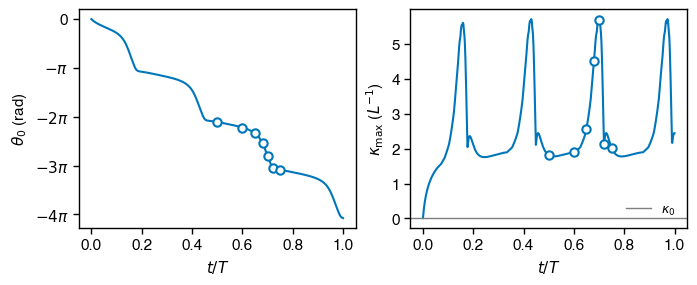

In [19]:
t_strided = frame_indices * dt
ori_strided = orientations[frame_indices]
dofs_strided = dofs[frame_indices]

orient_strided = dofs_strided[:, :N_ORIENT_DOFS]
curvature = np.diff(orient_strided, axis=1) / (2 * radius)   # curvature = Δθ / bond length
curvature_max = np.max(np.abs(curvature), axis=1) * L_chain  # normalise by chain length

# Lab-frame E_1 at each strided time, then its angle in (e1, e2)
# (unwrapped so the tumbling motion shows as a monotonic descent).
tangents = np.array([
    np.asarray(sm.rotation_matrix(ori)) @ np.array([1.0, 0.0, 0.0])
    for ori in ori_strided
])
theta_tan = np.unwrap(np.arctan2(tangents[:, 1], tangents[:, 0]))

# ===== USER: snapshot fractions of T_J (reused in cell 18 for the shape stack) =====
SNAP_FRACTIONS = [0.50, 0.60, 0.65, 0.68, 0.70, 0.72,0.75, ]
# ====================================================================================
snap_times = np.array([f * T_J for f in SNAP_FRACTIONS])
snap_frames = np.array([int(np.argmin(np.abs(t_strided - t))) for t in snap_times])
actual_times = t_strided[snap_frames]

fig_ts, axes_ts = figstyle.subplots(size="full", aspect=2.5, ncols=2, nrows=1)

axes_ts[0].plot(t_strided / T_J, theta_tan,
                color=figstyle.COLORS["blue"], linewidth=1.5)
axes_ts[0].plot(actual_times / T_J, theta_tan[snap_frames],
                marker="o", linestyle="", markersize=6,
                markeredgecolor=figstyle.COLORS["blue"],
                markerfacecolor="white", markeredgewidth=1.5)
# axes_ts[0].axhline(ALPHA_TILT, color=figstyle.COLORS["grey"],
#                    linestyle="--", linewidth=1.0)
axes_ts[0].set_xlabel(r"$t / T$")
axes_ts[0].set_ylabel(r"$\theta_0$ (rad)")
axes_ts[0].set_yticks([0, -np.pi, -2 * np.pi, -3 * np.pi, -4 * np.pi])
axes_ts[0].set_yticklabels(["0", r"$-\pi$", r"$-2\pi$", r"$-3\pi$", r"$-4\pi$"])

axes_ts[1].plot(t_strided / T_J, curvature_max,
                color=figstyle.COLORS["blue"], linewidth=1.5)
axes_ts[1].plot(actual_times / T_J, curvature_max[snap_frames],
                marker="o", linestyle="", markersize=6,
                markeredgecolor=figstyle.COLORS["blue"],
                markerfacecolor="white", markeredgewidth=1.5)
axes_ts[1].axhline(kappa_0 * L_chain, color=figstyle.COLORS["grey"],
                   linestyle="-", linewidth=1.0,
                   label=r"$\kappa_0$")
axes_ts[1].set_xlabel(r"$t / T$")
axes_ts[1].set_ylabel(r"$\kappa_\mathrm{max}$ ($L^{-1}$)")
axes_ts[1].legend(loc="best", frameon=False, fontsize=9)

figstyle.save(fig_ts, "fig_fiber_shear_timeseries", figdir=FIGDIR)

## 7. Shape snapshots

Each snapshot is COM-centred and placed left-to-right in time order
(earliest at the left). Snapshot times come from `SNAP_FRACTIONS` in
the cell above.

PosixPath('figures/fig_fiber_shear_shapes.pdf')

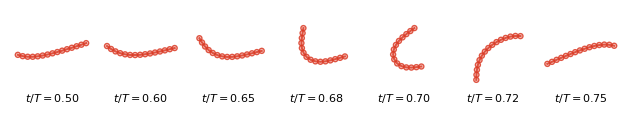

In [20]:
# Horizontal stack: each snapshot is COM-centred and shifted right by
# `x_step`. snap_frames / actual_times come from the time-series cell.
x_step = 1.25 * L_chain
y_half = 0.6 * L_chain

fig, ax = figstyle.figure(size="full", aspect=3.0)

for i, frame in enumerate(snap_frames):
    snap_xy = lab_pos_strided[frame][:, [0, 1]]
    centred = snap_xy - snap_xy.mean(axis=0)
    centred[:, 0] += i * x_step
    draw_shape(
        ax, centred,
        color=figstyle.COLORS["red"],
        fill=figstyle.COLORS["red_25"],
        bead_radius=radius,
        opacity=0.85,
    )
    ax.text(
        i * x_step, -y_half * 0.95,
        rf"$t/T = {actual_times[i] / T_J:.2f}$",
        fontsize=8, ha="center", va="top",
        color=figstyle.COLORS["black"],
    )

ax.set_xlim(-0.6 * L_chain, (len(snap_frames) - 1) * x_step + 0.6 * L_chain)
ax.set_ylim(-y_half, y_half)
ax.set_aspect("equal")
ax.set_axis_off()

figstyle.save(fig, "fig_fiber_shear_shapes", figdir=FIGDIR)

## Summary

This prototype simulates a rigid-bond chain of $N=15$ touching spheres in
simple shear, qualitatively reproducing **figure 8(b)** of Delmotte,
Climent & Plouraboué 2015: the buckling of a fiber with small
permanent curvature $\kappa_0$. Observations from the run above:

**Remark:** In the absence of intrinsic curvature ($\kappa_0=0$), we do not
recover a S shape when the fiber is oriented perpendicular to the flow, 
along $\mathbf{e}_2$ (Fig. 8a in Delmotte et al. 2015). 

## References

B. Delmotte, E. Climent, and F. Plouraboué, A general formulation of bead models applied to flexible fibers and active
filaments at low Reynolds number, *J. Comp. Phys.* **286**, 14 (2015).

Y. Liu, B. Chakrabarti, D. Saintillan, A. Lindner, and O. Du Roure, Morphological transitions of elastic filaments in shear
flow, *PNAS* **115**, 9438 (2018).

C. F. Schmid, L. H. Switzer, and D. J. Klingenberg, Simulations of fiber flocculation: Effects of fiber properties and
interfiber friction, *J. Rheol.* **44**, 781 (2000).